# Exercícios (Téoricos e Prático): Modelagem da equação do calor e técnica de discretização
## PPG-Biometria
### Disciplina: Matemática Aplicada 
### Professor: Fernando Luiz Pio dos Santos
### Aluno: Vitor Eduardo Girotto Barelli

## Objetivos
- Resolver numericamente a equação do calor estacionária 1D por diferenças finitas;
- Comparar a solução numérica com a solução analítica;
- Analisar propriedades da matriz do sistema linear;
- Resolver computacionalmente o problema com \( f(x)=4\pi^2\sin(2\pi x) \);
- Comparar a solução numérica com a solução exata e analisar o erro.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parte 1: Questões 2 e 3

Resolver o problema

\[
-u''(x)=50, \qquad 0<x<1
\]

com condições de contorno

\[
u(0)=0, \qquad u(1)=0
\]

utilizando diferenças finitas com passo

\[
h=\frac{1}{6}.
\]

In [2]:
# =========================
# PARÂMETROS DA PARTE 1
# =========================
f_const = 50
h = 1/6
k = 1

# Malha correta: exatamente 7 nós entre 0 e 1
x = np.linspace(0, 1, 7)
n_internos = len(x) - 2

print("Nós da malha da Parte 1:")
print(x)
print("\nNúmero de pontos internos:", n_internos)

Nós da malha da Parte 1:
[0.         0.16666667 0.33333333 0.5        0.66666667 0.83333333
 1.        ]

Número de pontos internos: 5


A discretização por diferenças finitas centradas fornece

\[
u''(x_i)\approx \frac{u_{i-1}-2u_i+u_{i+1}}{h^2}.
\]

Como o problema é

\[
-u''(x)=50,
\]

obtém-se

\[
-u_{i-1}+2u_i-u_{i+1}=50h^2.
\]

Isso leva a um sistema linear da forma

\[
Au=b.
\]

In [3]:
# =========================
# MONTAGEM DO SISTEMA LINEAR DA PARTE 1
# =========================
A = 2*np.eye(n_internos) - np.eye(n_internos, k=1) - np.eye(n_internos, k=-1)
b = (h**2 / k) * f_const * np.ones(n_internos)

print("Matriz A:")
print(A)

print("\nVetor b:")
print(b)

Matriz A:
[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]

Vetor b:
[1.38888889 1.38888889 1.38888889 1.38888889 1.38888889]


In [4]:
# =========================
# SOLUÇÃO NUMÉRICA DA PARTE 1
# =========================
u_interno = np.linalg.solve(A, b)

u_numerica = np.zeros(len(x))
u_numerica[1:-1] = u_interno

print("Solução numérica nos pontos internos:")
for i, val in enumerate(u_interno, start=1):
    print(f"u_{i} = {val:.10f}")

print("\nSolução numérica completa:")
print(u_numerica)

Solução numérica nos pontos internos:
u_1 = 3.4722222222
u_2 = 5.5555555556
u_3 = 6.2500000000
u_4 = 5.5555555556
u_5 = 3.4722222222

Solução numérica completa:
[0.         3.47222222 5.55555556 6.25       5.55555556 3.47222222
 0.        ]


A solução analítica do problema

\[
-u''(x)=50, \qquad u(0)=u(1)=0
\]

é

\[
u(x)=25x(1-x).
\]

In [5]:
# =========================
# SOLUÇÃO ANALÍTICA DA PARTE 1
# =========================
def u_analitica(x):
    return 25 * x * (1 - x)

x_fino = np.linspace(0, 1, 400)
u_analitica_fina = u_analitica(x_fino)
u_analitica_nos = u_analitica(x)

## Comparação entre solução numérica e analítica

In [6]:
# =========================
# COMPARAÇÃO ENTRE SOLUÇÃO NUMÉRICA E ANALÍTICA
# =========================
print("Comparação entre solução numérica e analítica:")
print("   x_i        u_numérica      u_analítica      erro absoluto")

for xi, un, ua in zip(x, u_numerica, u_analitica_nos):
    erro = abs(un - ua)
    print(f"{xi:7.4f}    {un:12.8f}    {ua:12.8f}    {erro:12.8e}")

Comparação entre solução numérica e analítica:
   x_i        u_numérica      u_analítica      erro absoluto
 0.0000      0.00000000      0.00000000    0.00000000e+00
 0.1667      3.47222222      3.47222222    4.44089210e-16
 0.3333      5.55555556      5.55555556    8.88178420e-16
 0.5000      6.25000000      6.25000000    1.77635684e-15
 0.6667      5.55555556      5.55555556    0.00000000e+00
 0.8333      3.47222222      3.47222222    1.77635684e-15
 1.0000      0.00000000      0.00000000    0.00000000e+00


## Gráfico da comparação

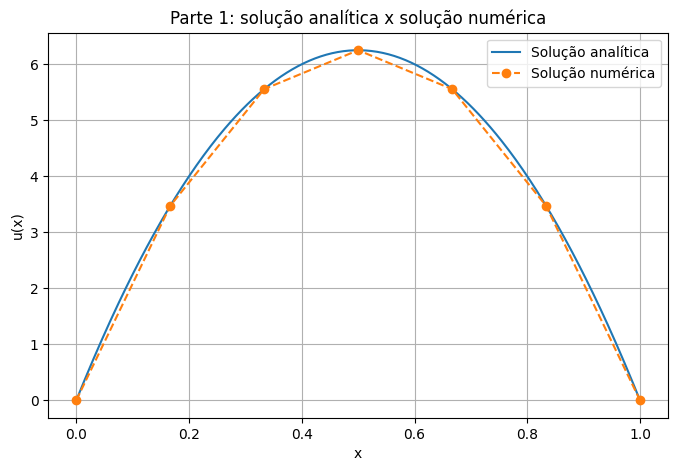

In [7]:
# =========================
# GRÁFICO DA PARTE 1
# =========================
plt.figure(figsize=(8,5))
plt.plot(x_fino, u_analitica_fina, label='Solução analítica')
plt.plot(x, u_numerica, 'o--', label='Solução numérica')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Parte 1: solução analítica x solução numérica')
plt.grid(True)
plt.legend()
plt.savefig('grafico_problema1_corrigido.png', dpi=300, bbox_inches='tight')
plt.show()

No caso da Parte 1, a solução numérica coincide com a solução analítica nos nós da malha. Isso ocorre porque a solução exata é quadrática, e a aproximação centrada da derivada segunda é exata para polinômios de grau 2.

## Parte 2: Questões 4 e 5

Resolver o problema

\[
-u''(x)=4\pi^2\sin(2\pi x), \qquad 0<x<1
\]

com condições de contorno

\[
u(0)=0, \qquad u(1)=0
\]

utilizando diferenças finitas com passo

\[
h=\frac{1}{4},
\]

e comparar com a solução exata

\[
u(x)=\sin(2\pi x).
\]

In [8]:
# =========================
# PARÂMETROS DA PARTE 2
# =========================
h2 = 1/4
k2 = 1

# Malha correta da Parte 2
x2 = np.linspace(0, 1, 5)
x2_interno = x2[1:-1]
n2 = len(x2_interno)

print("Nós da malha da Parte 2:")
print(x2)

print("\nPontos internos:")
print(x2_interno)

Nós da malha da Parte 2:
[0.   0.25 0.5  0.75 1.  ]

Pontos internos:
[0.25 0.5  0.75]


In [9]:
# =========================
# FUNÇÃO FONTE E SOLUÇÃO EXATA DA PARTE 2
# =========================
def f2(x):
    return 4 * np.pi**2 * np.sin(2 * np.pi * x)

def u_exata2(x):
    return np.sin(2 * np.pi * x)

A discretização do problema da Parte 2 leva ao sistema

\[
-u_{i-1}+2u_i-u_{i+1}=h^2f(x_i), \qquad i=1,2,3.
\]

Logo, novamente obtemos um sistema linear da forma

\[
A_2u=b_2.
\]

In [10]:
# =========================
# MONTAGEM DO SISTEMA LINEAR DA PARTE 2
# =========================
A2 = 2*np.eye(n2) - np.eye(n2, k=1) - np.eye(n2, k=-1)
b2 = (h2**2 / k2) * f2(x2_interno)

print("Matriz A2:")
print(A2)

print("\nVetor b2:")
print(b2)

Matriz A2:
[[ 2. -1.  0.]
 [-1.  2. -1.]
 [ 0. -1.  2.]]

Vetor b2:
[ 2.46740110e+00  3.02169486e-16 -2.46740110e+00]


## Resolução numérica

In [11]:
# =========================
# SOLUÇÃO NUMÉRICA DA PARTE 2
# =========================
u2_interno = np.linalg.solve(A2, b2)

u2_numerica = np.zeros(len(x2))
u2_numerica[1:-1] = u2_interno

print("Solução numérica nos pontos internos:")
for i, val in enumerate(u2_interno, start=1):
    print(f"u_{i} = {val:.10f}")

print("\nSolução numérica completa:")
print(u2_numerica)

Solução numérica nos pontos internos:
u_1 = 1.2337005501
u_2 = 0.0000000000
u_3 = -1.2337005501

Solução numérica completa:
[ 0.00000000e+00  1.23370055e+00  2.96059473e-16 -1.23370055e+00
  0.00000000e+00]


## Solução exata

In [12]:
# =========================
# SOLUÇÃO EXATA E ERRO NA PARTE 2
# =========================
x2_fino = np.linspace(0, 1, 400)
u2_exata_fina = u_exata2(x2_fino)
u2_exata_nos = u_exata2(x2)

erro2 = np.abs(u2_numerica - u2_exata_nos)

print("Comparação entre solução numérica e exata:")
print("   x_i        u_numérica      u_exata          erro absoluto")

for xi, un, ue, er in zip(x2, u2_numerica, u2_exata_nos, erro2):
    print(f"{xi:7.4f}    {un:12.8f}    {ue:12.8f}    {er:12.8e}")

Comparação entre solução numérica e exata:
   x_i        u_numérica      u_exata          erro absoluto
 0.0000      0.00000000      0.00000000    0.00000000e+00
 0.2500      1.23370055      1.00000000    2.33700550e-01
 0.5000      0.00000000      0.00000000    1.73594793e-16
 0.7500     -1.23370055     -1.00000000    2.33700550e-01
 1.0000      0.00000000     -0.00000000    2.44929360e-16


## Gráfico da comparação

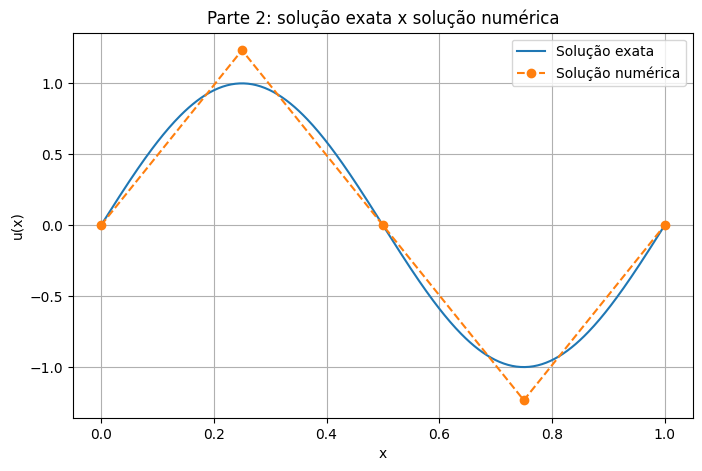

In [13]:
# =========================
# GRÁFICO DA PARTE 2
# =========================
plt.figure(figsize=(8,5))
plt.plot(x2_fino, u2_exata_fina, label='Solução exata')
plt.plot(x2, u2_numerica, 'o--', label='Solução numérica')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('Parte 2: solução exata x solução numérica')
plt.grid(True)
plt.legend()
plt.savefig('grafico_problema2.png', dpi=300, bbox_inches='tight')
plt.show()

## Gráfico do erro

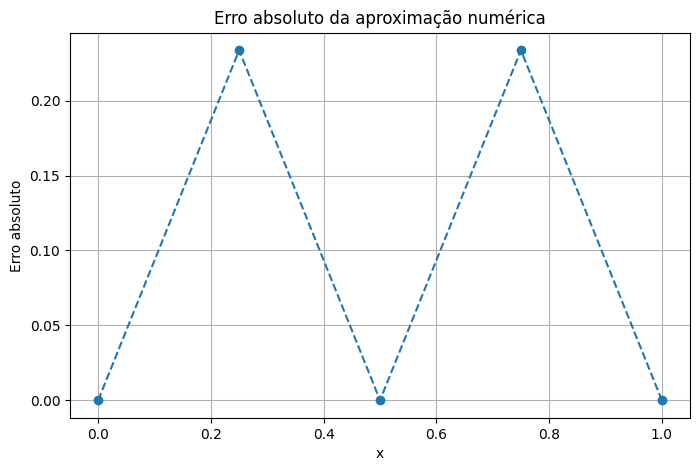

In [14]:
# =========================
# GRÁFICO DO ERRO NA PARTE 2
# =========================
plt.figure(figsize=(8,5))
plt.plot(x2, erro2, 'o--')
plt.xlabel('x')
plt.ylabel('Erro absoluto')
plt.title('Erro absoluto da aproximação numérica')
plt.grid(True)
plt.savefig('grafico_erro_problema2.png', dpi=300, bbox_inches='tight')
plt.show()

Na Parte 2, a solução numérica aproxima adequadamente a solução exata, mas apresenta erro não nulo nos pontos laterais da malha. O erro é zero no ponto central e nos pontos de contorno, e é máximo em \(x=1/4\) e \(x=3/4\).

In [17]:
# =========================
# PROPRIEDADES DA MATRIZ DA PARTE 1
# =========================
print("Propriedades da matriz A da Parte 1:")
print("1. Simétrica")
print("2. Tridiagonal e esparsa")
print("3. Definida positiva")

Propriedades da matriz A da Parte 1:
1. Simétrica
2. Tridiagonal e esparsa
3. Definida positiva
